# Bidirectional Translation Full Fine-Tuning with NLLB

## Overview
This notebook implements a **Full Fine-Tuning (FFT)** strategy for the **NLLB-200-distilled-600M** model. The objective is to significantly enhance bidirectional translation performance between **Odia (ory_Orya)** and **German (deu_Latn)**, a low-resource language pair. By updating all model parameters, this approach aims to maximize the model's alignment with the complex morphology of Odia and the semantic structures of German.

## Key Experiments
1.  **Baseline Evaluation**: Assessed the pre-trained `facebook/nllb-200-distilled-600M` model in a zero-shot setting using 8-bit quantization.
2.  **Full Fine-Tuning**: Trained for 3 epochs with a learning rate of 2e-5, effective batch size of 16 (batch 4, accumulation 4), and Adafactor optimizer.
3.  **Comparative Analysis**: Benchmarked the Fine-Tuned (FFT) model against the Baseline using BLEU, chrF++, TER, and COMET.
4.  **Statistical Significance**: Using paired bootstrap resampling to validate performance gains.

## Requirements
* **Hardware**: A100 GPU (High-RAM)
* **Libraries**: `transformers`, `datasets`, `bitsandbytes`, `sacrebleu`, `unbabel-comet`, `evaluate`, `matplotlib` & `seaborn`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q transformers sacrebleu torch accelerate pandas bitsandbytes unbabel-comet evaluate

In [ ]:
print("--- All Installed Packages (pip list) ---")
!pip list

--- All Installed Packages (pip list) ---
Package                                  Version
---------------------------------------- --------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.2
aiosignal                                1.4.0
aiosqlite                                0.22.0
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.17.2
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime            

In [ ]:
# import required libraries
import json
import torch
from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets
from evaluate import load as load_metric
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sacrebleu
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, pipeline
from tqdm.auto import tqdm
from transformers import BitsAndBytesConfig
import random
from collections import defaultdict
import pickle
import os

In [ ]:
# --- METRIC LOADING ---
print("Loading COMET metric...")
try:
    comet_metric = load_metric("comet", "Unbabel/wmt20-comet-da")
    print("COMET metric loaded successfully.")
except Exception as e:
    print(f"Error loading COMET metric: {e}. Falling back to default metrics.")
    comet_metric = None

Loading COMET metric...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

checkpoints/model.ckpt:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

hparams.yaml:   0%|          | 0.00/437 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

COMET metric loaded successfully.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [ ]:
# --- CONFIGURATION ---

# 1. DATA PATHS
DATA_DIR = "/content/drive/MyDrive/Research_Paper_Publication/data/transformed/"
TRAIN_FILE = os.path.join(DATA_DIR, "train_bidirectional.jsonl")
VAL_FILE = os.path.join(DATA_DIR, "val_bidirectional.jsonl")
TEST_FILE = os.path.join(DATA_DIR, "test_bidirectional.jsonl")

# 2. MODEL & OUTPUT PATHS
MODEL_NAME = "facebook/nllb-200-distilled-600M"
OUTPUT_DIR = "/content/drive/MyDrive/Research_Paper_Publication/eval/nllb-finetuned-odia-german-model-results_new_v1"
FINAL_MODEL_PATH = "/content/drive/MyDrive/Research_Paper_Publication/model/nllb-odia-german-translator_model_final_new_v1"
FFT_SCORE_PATH = "/content/drive/MyDrive/Research_Paper_Publication/eval/fft_sentence_scores_updated.pkl"

# --- Field Names ---
INPUT_FIELD = "input_text"
TARGET_FIELD = "target_text"

# --- Language Configuration ---
ODIA_LANG_CODE = "ory_Orya"
GERMAN_LANG_CODE = "deu_Latn"

# --- Task Prefixes ---
PREFIX_ORI_TO_DEU = "translate Odia to German: "
PREFIX_DEU_TO_ORI = "translate German to Odia: "

In [ ]:
# --- LOAD THE DATASET (LEAKAGE-FREE METHOD) ---

print("Loading pre-split bidirectional datasets...")

data_files = {
    "train": TRAIN_FILE,
    "validation": VAL_FILE,
    "test": TEST_FILE
}

# This loads the separate files directly into a DatasetDict
split_datasets = load_dataset("json", data_files=data_files)

print("Dataset loaded successfully.")
print(f"Training set size: {len(split_datasets['train'])}")
print(f"Validation set size: {len(split_datasets['validation'])}")
print(f"Test set size: {len(split_datasets['test'])}")

Loading pre-split bidirectional datasets...


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset loaded successfully.
Training set size: 5880
Validation set size: 736
Test set size: 736


In [ ]:
# --- Corpus Analysis (EDA) ---

print("\n--- Starting Corpus Analysis (EDA) ---")

# We temporarily combine them just to calculate total stats for the graphs
full_dataset_for_eda = concatenate_datasets([split_datasets['train'], split_datasets['validation'], split_datasets['test']])

print("Reconstructing original sentence pairs from data...")

# Extract Odia source sentences (filter for one direction to avoid duplicates in stats)
odia_source_sentences = [
    ex[INPUT_FIELD].replace(PREFIX_ORI_TO_DEU, "")
    for ex in full_dataset_for_eda
    if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)
]
german_target_sentences = [
    ex[TARGET_FIELD]
    for ex in full_dataset_for_eda
    if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)
]

print(f"Successfully extracted {len(odia_source_sentences)} unique parallel pairs for analysis.")


--- Starting Corpus Analysis (EDA) ---
Reconstructing original sentence pairs from data...
Successfully extracted 3676 unique parallel pairs for analysis.


In [ ]:
# --- Calculate Sentence Lengths ---
odia_lengths = [len(s.split()) for s in odia_source_sentences]
german_lengths = [len(s.split()) for s in german_target_sentences]

# --- Descriptive Statistics ---
stats_data = {
    'Language': ['Odia', 'German'],
    'Mean Length': [np.mean(odia_lengths), np.mean(german_lengths)],
    'Median Length': [np.median(odia_lengths), np.median(german_lengths)],
    'Std. Deviation': [np.std(odia_lengths), np.std(german_lengths)],
    'Max Length': [np.max(odia_lengths), np.max(german_lengths)]
}
df_stats = pd.DataFrame(stats_data).set_index('Language')

print("\n--- Corpus Statistics ---")
display(df_stats.style.format("{:.2f}"))


--- Corpus Statistics ---


,Mean Length,Median Length,Std. Deviation,Max Length
Language,,,,
Odia,24.82,26.00,8.42,47.00
German,25.80,26.00,9.97,68.00


* The mean lengths (24.82 vs 25.80) are remarkably balanced. This is good for the model, as it doesn't have to learn extreme compression or expansion of information.
* A standard deviation of ~8-10 indicates a healthy variety of sentence types (short simple phrases vs. longer complex sentences).


--- Generating Sentence Length Distribution Plot ---


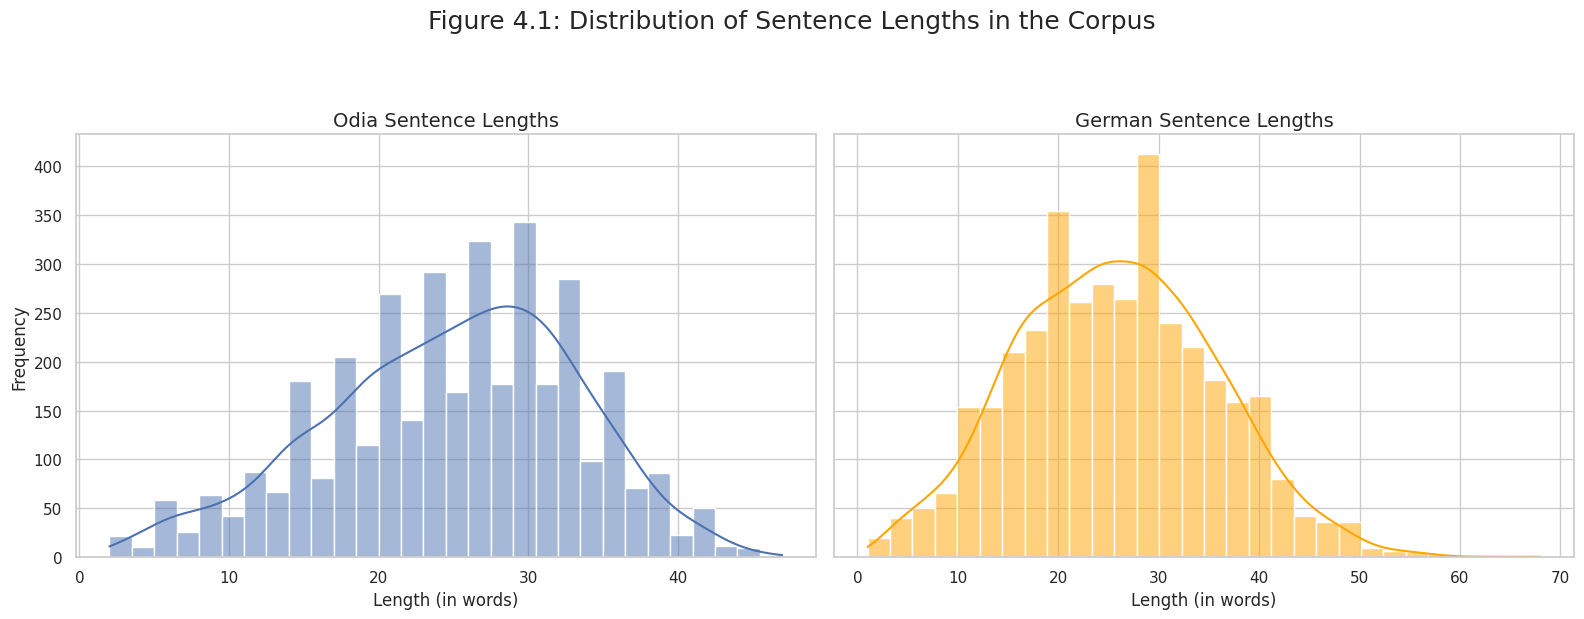


✅ Corpus Analysis complete.


In [ ]:
# --- Visualize Sentence Length Distribution ---
print("\n--- Generating Sentence Length Distribution Plot ---")

plot_df_odia = pd.DataFrame({'Sentence Length (words)': odia_lengths})
plot_df_odia['Language'] = 'Odia'
plot_df_german = pd.DataFrame({'Sentence Length (words)': german_lengths})
plot_df_german['Language'] = 'German'

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Figure 4.1: Distribution of Sentence Lengths in the Corpus', fontsize=18, y=1.03)

sns.histplot(data=plot_df_odia, x='Sentence Length (words)', ax=axes[0], kde=True, bins=30)
axes[0].set_title('Odia Sentence Lengths', fontsize=14)
axes[0].set_xlabel('Length (in words)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

sns.histplot(data=plot_df_german, x='Sentence Length (words)', ax=axes[1], kde=True, bins=30, color='orange')
axes[1].set_title('German Sentence Lengths', fontsize=14)
axes[1].set_xlabel('Length (in words)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n✅ Corpus Analysis complete.")

In [ ]:
# --- PREPARE TOKENIZER AND PREPROCESSING FUNCTION ---

print("\nLoading tokenizer...")

# Initialize the NLLB tokenizer.
# NLLB requires BCP-47 language codes (e.g., 'ory_Orya', 'deu_Latn').
# Setting src_lang and tgt_lang here ensures the tokenizer uses the correct
# special tokens (like starting the sequence with the correct language tag)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME,
                                          src_lang=ODIA_LANG_CODE,
                                          tgt_lang=GERMAN_LANG_CODE)

def preprocess_function(examples):
    """
    Tokenizes inputs and targets for Sequence-to-Sequence (Seq2Seq) training.

    This function processes a batch of raw text examples:
    1. Tokenizes the input text (Source Language) using standard encoding.
    2. Tokenizes the target text (Target Language) using the target-specific context.
    3. Formats the output to include 'input_ids', 'attention_mask', and 'labels'.

    Args:
        examples (dict): A dictionary containing 'input_text' and 'target_text'
                         lists from a dataset batch.

    Returns:
        dict: A dictionary containing the tokenized model inputs and labels.
    """
    inputs = examples[INPUT_FIELD]
    targets = examples[TARGET_FIELD]

    # Tokenize inputs (Source Language)
    # max_length=1200: Truncates sequences longer than 1200 tokens to prevent OOM errors.
    # truncation=True: Ensures strictly fixed-length or shorter sequences.
    model_inputs = tokenizer(inputs, max_length=1200, truncation=True)

    # Tokenize targets (Target Language)
    # The 'as_target_tokenizer()' context manager ensures that the tokenizer
    # uses the target language's special tokens and vocabulary settings.
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=1200, truncation=True)

    # Assign the tokenized target IDs to the 'labels' key.
    # The model expects 'labels' to calculate the CrossEntropyLoss during training.
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print("Tokenizing all dataset splits...")

# Apply the preprocessing function to the entire dataset.
# batched=True: Processes examples in chunks (batch_size=16) for speed.
# remove_columns: Removes the original raw text columns ('input_text', 'target_text')
#                 so the final dataset contains only the tensors required for training.
tokenized_datasets = split_datasets.map(preprocess_function,
                                        batched=True,
                                        batch_size=16,
                                        remove_columns=split_datasets['train'].column_names)
print("Tokenization complete.")


Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/5880 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4169: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Map:   0%|          | 0/736 [00:00<?, ? examples/s]

Tokenization complete.


In [ ]:
# --- Vocabulary Analysis ---
def calculate_vocab_size(sentences_list, tokenizer):
    """
    Calculates the number of unique tokens (vocabulary size) present in a list of sentences.

    This function iterates through a provided corpus, tokenizes each sentence using the
    specified tokenizer, and stores the unique tokens in a set to determine the
    lexical diversity of the dataset.

    Args:
        sentences_list (list of str): A list containing the sentences to be analyzed.
        tokenizer (PreTrainedTokenizer): A tokenizer instance (e.g., from Hugging Face)
                                         that has a `.tokenize()` method.

    Returns:
        int: The total count of unique tokens found across all sentences in the list.
    """
    # Use a set to automatically handle deduplication of tokens.
    unique_tokens = set()

    print(f"Tokenizing {len(sentences_list)} sentences...")

    # Iterate through the sentences with a progress bar (tqdm) to monitor processing speed.
    for sentence in tqdm(sentences_list):
        # Tokenize the raw sentence into subwords/tokens.
        tokens = tokenizer.tokenize(sentence)
        # Add new tokens to the set (duplicates are ignored automatically).
        unique_tokens.update(tokens)
    return len(unique_tokens)

# --- Execution ---
print("\nAnalyzing Odia corpus...")
# Calculate unique tokens for the Source Language (Odia) to understand input complexity.
odia_vocab_size = calculate_vocab_size(odia_source_sentences, tokenizer)

print("\nAnalyzing German corpus...")
# Calculate unique tokens for the Target Language (German) to understand output complexity.
german_vocab_size = calculate_vocab_size(german_target_sentences, tokenizer)

# --- Display Results ---
print("\n" + "="*50)
print(f"Unique Odia Tokens:   {odia_vocab_size}")
print(f"Unique German Tokens: {german_vocab_size}")
print("="*50)


Analyzing Odia corpus...
Tokenizing 3676 sentences...


  0%|          | 0/3676 [00:00<?, ?it/s]


Analyzing German corpus...
Tokenizing 3676 sentences...


  0%|          | 0/3676 [00:00<?, ?it/s]


Unique Odia Tokens:   2639
Unique German Tokens: 9698


In [ ]:
# =========================================================
# ========== STATISTICAL SIGNIFICANCE FUNCTION =============
# =========================================================

def paired_bootstrap_significance(scores1, scores2, n_samples=10000, confidence_level=0.95):
    """
    Computes statistical significance using Paired Bootstrap Resampling.

    This function determines if 'scores2' (Candidate Model) is statistically
    superior to 'scores1' (Baseline Model) by estimating the p-value of the
    hypothesis test.

    Methodology:
    1. Paired Testing: Uses element-wise differences (score2 - score1) to account
       for sentence-level difficulty variance.
    2. Bootstrap Resampling: Generates 'n_samples' synthetic test sets by sampling
       with replacement from the original differences.
    3. One-Tailed Test: Tests the hypothesis that Model 2 is better than Model 1
       (Mean Difference > 0). The p-value is the fraction of bootstrap samples
       where Model 2 failed to beat Model 1 (Mean Difference <= 0).

    Args:
        scores1 (list or np.array): Metric scores (e.g., BLEU, chrF) for the Baseline model.
        scores2 (list or np.array): Metric scores for the Candidate model (must be same length).
        n_samples (int): Number of bootstrap iterations. Defaults to 10000
        confidence_level (float): The confidence threshold (1 - alpha).
                                  Defaults to 0.95 (implying alpha=0.05).

    Returns:
        tuple: (p_value_one_tailed, is_significant)
              - p_value_one_tailed (float): Probability that the improvement is due to chance.
              - is_significant (bool): True if p_value < (1 - confidence_level).

    Raises:
        ValueError: If the input score lists are not of equal length.
    """
    # 1. Validation: Ensure both models were evaluated on the exact same test set.
    if len(scores1) != len(scores2):
        raise ValueError("Score lists must be of the same length for paired testing.")

    n_sentences = len(scores1)

    # 2. Compute Paired Differences (Delta)
    # We analyze the difference per sentence rather than the absolute means.
    # This reduces variance caused by "easy" or "hard" sentences in the test set.
    diffs = [s2 - s1 for s1, s2 in zip(scores1, scores2)]

    bootstrap_diffs = []

    # 3. Bootstrap Loop
    # We resample the *differences* with replacement to estimate the distribution of the mean difference.
    # Using 'tqdm' provides a progress bar for large n_samples.
    for _ in tqdm(range(n_samples), desc="Bootstrap Resampling"):
        # Resample indices with replacement (some sentences picked multiple times, some zero)
        sample_indices = random.choices(range(n_sentences), k=n_sentences)

        # Calculate the mean improvement for this specific bootstrap sample
        sample_diff = np.mean([diffs[i] for i in sample_indices])
        bootstrap_diffs.append(sample_diff)

    # 4. Calculate P-Value (One-Tailed)
    # Null Hypothesis (H0): Model 2 is NOT better than Model 1 (Mean Diff <= 0).
    # The p-value is the probability of observing H0 in our bootstrap distribution.
    # We count how often the resampled improvement was zero or negative.
    p_value_one_tailed = np.sum(np.array(bootstrap_diffs) <= 0) / n_samples

    # 5. Determine Significance
    # Compare p-value against the significance level alpha (e.g., 0.05).
    alpha = 1.0 - confidence_level
    is_significant = p_value_one_tailed < alpha

    return p_value_one_tailed, is_significant

In [ ]:
# --- EVALUATION LOGIC ---
def evaluate_model_on_task(model_to_eval, tokenizer, test_data, task_prefix, src_lang, tgt_lang, batch_size=8, return_sentence_scores=False):
    """
    Evaluates a fine-tuned translation model on a specific language direction using
    standard metrics (BLEU, chrF, TER, and COMET).

    This function filters the test dataset for a specific task (based on the input prefix),
    generates translations in batches, and computes both corpus-level and optionally
    sentence-level metrics.

    Args:
        model_to_eval (PreTrainedModel): The Hugging Face model object to evaluate.
        tokenizer (PreTrainedTokenizer): The tokenizer associated with the model.
        test_data (list of dict): The full test dataset containing 'input_text' and 'target_text'.
        task_prefix (str): The specific prefix used to filter examples for this task
                           (e.g., "translate Odia to German: ").
        src_lang (str): The source language code (e.g., 'ory_Orya').
        tgt_lang (str): The target language code (e.g., 'deu_Latn').
        batch_size (int): Number of sentences to process per inference batch. Defaults to 8.
        return_sentence_scores (bool): If True, returns a list of individual BLEU scores
                                       for statistical testing. Defaults to False.

    Returns:
        dict or tuple:
            - If return_sentence_scores is False: Returns a dictionary of metric scores
              {'bleu': float, 'chrf': float, 'ter': float, 'comet': float}.
            - If return_sentence_scores is True: Returns a tuple (metrics_dict, sentence_scores_list).
    """
    # 1. Filter Data: Extract only the examples matching the requested task prefix.
    task_entries = [ex for ex in test_data if ex[INPUT_FIELD].startswith(task_prefix)]
    task_inputs = [ex[INPUT_FIELD] for ex in task_entries]

    # 2. Prepare References
    # 'task_references_list': Flat list for COMET and sentence-level iteration.
    task_references_list = [ex[TARGET_FIELD] for ex in task_entries]

    # 'task_references_sacrebleu': SacreBLEU expects a list of reference lists
    # (supporting multiple references per sentence), i.e., [[ref1_a, ref2_a...], [ref1_b...]].
    # Since we have single references, we wrap the list once.
    task_references_sacrebleu = [task_references_list]

    # Handle edge case: Return zeros if no data exists for this direction.
    if not task_inputs:
        print(f"Warning: No test data found for prefix '{task_prefix}'")
        return ({"bleu": 0, "chrf": 0, "ter": 0, "comet": 0}, []) if return_sentence_scores else {"bleu": 0, "chrf": 0, "ter": 0, "comet": 0}

    # 3. Prepare Sources for COMET
    # COMET expects the raw source sentence without the T5/NLLB task prefix.
    comet_sources = [inp.replace(task_prefix, "") for inp in task_inputs]

    # 4. Inference Pipeline
    # Using the high-level 'pipeline' API for efficient batch generation.
    translator = pipeline("translation", model=model_to_eval, tokenizer=tokenizer, src_lang=src_lang, tgt_lang=tgt_lang)
    decoded_preds = []

    print(f"Generating translations for {len(task_inputs)} sentences...")
    # Iterate through inputs in batches to optimize GPU usage.
    for i in tqdm(range(0, len(task_inputs), batch_size)):
        batch = task_inputs[i : i + batch_size]
        predictions = translator(batch, max_length=1200)
        # Extract the text string from the pipeline output dict
        decoded_preds.extend([pred['translation_text'] for pred in predictions])

    # 5. Compute Corpus Metrics (SacreBLEU)
    # BLEU: Precision-based (n-gram overlap).
    bleu = sacrebleu.BLEU().corpus_score(decoded_preds, task_references_sacrebleu).score
    # chrF: Character n-gram F-score (often better for morphologically rich languages).
    chrf = sacrebleu.CHRF(word_order=2).corpus_score(decoded_preds, task_references_sacrebleu).score
    # TER: Translation Edit Rate (number of edits required to match reference).
    ter = sacrebleu.TER().corpus_score(decoded_preds, task_references_sacrebleu).score

    # 6. Compute Sentence-Level Scores
    # Used for statistical significance testing (Paired Bootstrap).
    sentence_scores = []
    if return_sentence_scores:
        sbleu = sacrebleu.BLEU(effective_order=True)
        sentence_scores = [sbleu.sentence_score(pred, [ref]).score for pred, ref in zip(decoded_preds, task_references_list)]

    # 7. Compute COMET Score (Neural Metric)
    # Checks if the global 'comet_metric' object is initialized.
    comet_score = 0
    if comet_metric is not None:
        # COMET requires the triplet: (Source, Hypothesis, Reference)
        comet_results = comet_metric.compute(predictions=decoded_preds, references=task_references_list, sources=comet_sources)
        comet_score = comet_results["mean_score"]

    metrics_dict = {"bleu": bleu, "chrf": chrf, "ter": ter, "comet": comet_score}

    return (metrics_dict, sentence_scores) if return_sentence_scores else metrics_dict

In [ ]:
# --- BASELINE EVALUATION ---
print("\n--- Evaluating Baseline Model (Before Fine-Tuning) ---")

# 1. Configure Quantization
# We use BitsAndBytesConfig to load the model in 8-bit precision.
# This reduces memory footprint (VRAM usage) significantly while preserving
# most of the original model's accuracy, allowing inference on limited hardware.
bnb_config = BitsAndBytesConfig(load_in_8bit=True)

# 2. Load the Pre-trained Baseline Model
# device_map="auto": Automatically offloads layers to CPU if GPU memory is full,
# ensuring the model loads successfully even on smaller GPUs.
base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME,
                                                   quantization_config=bnb_config,
                                                   device_map="auto")

# 3. Evaluate Baseline: Odia -> German
# We enable 'return_sentence_scores=True' to store individual sentence BLEU scores.
# These will be used later for statistical significance testing against the fine-tuned model.
baseline_ori_deu_metrics, baseline_ori_deu_scores = evaluate_model_on_task(base_model,
                                                                           tokenizer,
                                                                           split_datasets['test'],
                                                                           PREFIX_ORI_TO_DEU,
                                                                           ODIA_LANG_CODE,
                                                                           GERMAN_LANG_CODE,
                                                                           return_sentence_scores=True)

# 4. Evaluate Baseline: German -> Odia
# Evaluate the reverse direction to establish the baseline performance
# for generating the low-resource language.
baseline_deu_ori_metrics, baseline_deu_ori_scores = evaluate_model_on_task(base_model,
                                                                           tokenizer,
                                                                           split_datasets['test'],
                                                                           PREFIX_DEU_TO_ORI,
                                                                           GERMAN_LANG_CODE,
                                                                           ODIA_LANG_CODE,
                                                                           return_sentence_scores=True)


--- Evaluating Baseline Model (Before Fine-Tuning) ---


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

...

  0%|          | 0/46 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/

Generating translations for 368 sentences...


  0%|          | 0/46 [00:00<?, ?it/s]

This is a friendly reminder - the current text generation call has exceeded the model's predefined maximum length (1024). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# =========================================================
# ========= FULL FINE-TUNING EXECUTION ====================
# =========================================================

# 1. Clean Up Memory
# We delete the 'base_model' used for baseline evaluation to free up GPU VRAM.
# This prevents "Out of Memory" (OOM) errors before loading the model for training.
del base_model
torch.cuda.empty_cache()

In [ ]:
# --- FULL FINE-TUNING THE MODEL ---
print("\n--- Starting Fine-Tuning Process ---")

# 2. Reload Model for Training
# We reload the model from scratch (without 8-bit quantization) to ensure stable training gradients.
# Standard fp32 or fp16 is preferred over 8-bit for the backward pass during full fine-tuning.
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

def compute_metrics_for_trainer(eval_preds):
    """
    Callback function to compute evaluation metrics during training.

    This function is called by the Seq2SeqTrainer at the end of every evaluation epoch.
    It decodes the raw logits into text and computes the BLEU score to monitor progress.

    Args:
        eval_preds (tuple): A tuple containing:
            - preds (np.ndarray): The raw predictions (logits) from the model.
            - labels (np.ndarray): The tokenized reference labels.

    Returns:
        dict: A dictionary containing the computed metrics (e.g., {'bleu': 24.5}).
    """
    preds, labels = eval_preds

    # Handle tuple predictions (some models return (logits, encoder_outputs))
    if isinstance(preds, tuple):
        preds = preds[0]

    # Decode Predictions
    # Convert token IDs back to strings, skipping special tokens like [PAD], [EOS].
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # Decode Labels
    # -100 is a default ignore index in Hugging Face loss functions.
    # We replace it with the PAD token ID so decoding doesn't fail.
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # SacreBLEU formatting: It expects a list of reference lists.
    decoded_labels_formatted = [decoded_labels]

    # Compute BLEU
    result = sacrebleu.BLEU().corpus_score(decoded_preds, decoded_labels_formatted)

    return {"bleu": result.score}

# 3. Define Training Arguments
# These hyperparameters control the optimization and resource management.
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    # Evaluation Strategy
    eval_strategy="epoch",    # Run evaluation at the end of every epoch.
    save_strategy="epoch",    # Save a checkpoint at the end of every epoch.

    # Hyperparameters
    learning_rate=2e-5,               # Standard fine-tuning rate for Transformers.
    per_device_train_batch_size=4,    # Small batch size to fit in VRAM.
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,    # Simulates a batch size of 16 (4x4).
    weight_decay=0.01,                # Regularization to prevent overfitting.
    num_train_epochs=3,               # Number of full passes over the dataset.

    # Checkpointing & Memory Efficiency
    save_total_limit=2,               # Keep only the last 2 checkpoints to save disk space.
    predict_with_generate=True,       # Critical for Seq2Seq: Uses generation (beam search) for metrics, not just logits.
    fp16=torch.cuda.is_available(),   # Use mixed precision (float16) if GPU supports it (speedup).
    gradient_checkpointing=True,      # Saves VRAM by recomputing activations during backward pass.

    # Model Selection
    load_best_model_at_end=True,      # Load the checkpoint with the highest BLEU at the end.
    metric_for_best_model="bleu",
    greater_is_better=True,

    # Optimizer
    optim="adafactor",                # Adafactor is often more memory-efficient than AdamW for T5/NLLB models.
    report_to="none"                  # Disable W&B/Tensorboard logging for this run.
)

# 4. Initialize Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model),
    compute_metrics=compute_metrics_for_trainer,
)

# 5. Execute Training
trainer.train()


--- Starting Fine-Tuning Process ---


`use_cache=True` is incompatible with gradient checkpointing`. Setting `use_cache=False`...


Epoch,Training Loss,Validation Loss,Bleu
1,No log,1.344404,19.380633
2,1.574000,1.307946,19.887804
3,1.340100,1.300245,20.093857


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=1104, training_loss=1.4427709717681443, metrics={'train_runtime': 1578.3399, 'train_samples_per_second': 11.176, 'train_steps_per_second': 0.699, 'total_flos': 2951621863833600.0, 'train_loss': 1.4427709717681443, 'epoch': 3.0})

### Observation

1. `Steady Improvement:` The model is learning successfully. The BLEU score increased consistently from 19.38 $\to$ 20.09.

2. `Convergence:` The validation loss dropped significantly from Epoch 1 to 2, but flattened out between Epoch 2 (1.307) and Epoch 3 (1.300). This suggests that 3 epochs was the correct choice. Training longer might have led to overfitting (where validation loss starts increasing).

In [ ]:
# --- FINAL EVALUATION ---
print("\n--- Evaluating Fine-Tuned Model ---")

# 1. Identify Best Checkpoint
# The Trainer tracks the best model based on the 'metric_for_best_model' (BLEU)
# defined in TrainingArguments. We retrieve the path to that specific checkpoint.
best_checkpoint_path = trainer.state.best_model_checkpoint
print(f"Loading best fine-tuned model from: {best_checkpoint_path}")

# 2. Load the Fine-Tuned Model
# We load the model from the best checkpoint to ensure we evaluate the optimal version.
# load_in_8bit=True: Re-enabling quantization for inference to save memory,
# similar to the baseline evaluation setup.
finetuned_model = AutoModelForSeq2SeqLM.from_pretrained(best_checkpoint_path,
                                                        load_in_8bit=True,
                                                        device_map="auto")

# 3. Evaluate Fine-Tuned: Odia -> German
# We pass 'return_sentence_scores=True' to capture individual sentence BLEU scores
# for subsequent statistical significance testing against the baseline.
print("Evaluating Odia -> German fine-tuned...")
finetuned_ori_deu_metrics, finetuned_ori_deu_scores = evaluate_model_on_task(finetuned_model,
                                                                             tokenizer,
                                                                             split_datasets['test'],
                                                                             PREFIX_ORI_TO_DEU,
                                                                             ODIA_LANG_CODE,
                                                                             GERMAN_LANG_CODE,
                                                                             return_sentence_scores=True)

# 4. Evaluate Fine-Tuned: German -> Odia
# Running evaluation on the reverse direction to check improvements in generating Odia.
print("Evaluating German -> Odia fine-tuned...")
finetuned_deu_ori_metrics, finetuned_deu_ori_scores = evaluate_model_on_task(finetuned_model,
                                                                             tokenizer,
                                                                             split_datasets['test'],
                                                                             PREFIX_DEU_TO_ORI,
                                                                             GERMAN_LANG_CODE,
                                                                             ODIA_LANG_CODE,
                                                                             return_sentence_scores=True)

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.



--- Evaluating Fine-Tuned Model ---
Loading best fine-tuned model from: /content/drive/MyDrive/Research_Paper_Publication/eval/nllb-finetuned-odia-german-model-results_new_v1/checkpoint-1104


Device set to use cuda:0


Evaluating Odia -> German fine-tuned...
Generating translations for 368 sentences...


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Device set to use cuda:0


Evaluating German -> Odia fine-tuned...
Generating translations for 368 sentences...


  0%|          | 0/46 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# --- DISPLAY FINAL RESULTS TABLE ---

# 1. Aggregate Results
# Construct a dictionary to organize metrics from all four experimental conditions:
# - Odia -> German (Baseline & Fine-Tuned)
# - German -> Odia (Baseline & Fine-Tuned)
results_data = {
    'Metric': ['BLEU', 'chrF++', 'TER (lower is better)', 'COMET'],
    # Extract values from the metric dictionaries computed earlier.
    'Odia → German (Baseline)': [baseline_ori_deu_metrics['bleu'],
                                 baseline_ori_deu_metrics['chrf'],
                                 baseline_ori_deu_metrics['ter'],
                                 baseline_ori_deu_metrics['comet']],
    'Odia → German (Fine-Tuned)': [finetuned_ori_deu_metrics['bleu'],
                                   finetuned_ori_deu_metrics['chrf'],
                                   finetuned_ori_deu_metrics['ter'],
                                   finetuned_ori_deu_metrics['comet']],
    'German → Odia (Baseline)': [baseline_deu_ori_metrics['bleu'],
                                 baseline_deu_ori_metrics['chrf'],
                                 baseline_deu_ori_metrics['ter'],
                                 baseline_deu_ori_metrics['comet']],
    'German → Odia (Fine-Tuned)': [finetuned_deu_ori_metrics['bleu'],
                                   finetuned_deu_ori_metrics['chrf'],
                                   finetuned_deu_ori_metrics['ter'],
                                   finetuned_deu_ori_metrics['comet']],
}

# 2. Create DataFrame
# Convert the dictionary to a Pandas DataFrame and set 'Metric' as the index
# for a cleaner, matrix-like presentation.
df_results = pd.DataFrame(results_data).set_index('Metric')
print("\n\n" + "="*80)

# 3. Print Header
print("------------- FINAL PERFORMANCE RESULTS --------------")
print("="*80)

# 4. Render Table
# Use Pandas Styler to format numbers to 4 decimal places for precision.
# Note: 'display()' is a Jupyter/Colab specific function. If running as a
# standard script, use 'print(df_results)' instead.
display(df_results.style.format("{:.4f}"))

print("="*80)



------------- FINAL PERFORMANCE RESULTS --------------


,Odia → German (Baseline),Odia → German (Fine-Tuned),German → Odia (Baseline),German → Odia (Fine-Tuned)
Metric,,,,
BLEU,22.0355,27.1802,9.3467,14.8624
chrF++,43.3357,54.3083,38.3720,43.4127
TER (lower is better),82.7669,64.5270,97.6340,74.4360
COMET,-0.0285,0.5479,0.1876,0.8167


### Observation

The results table indicates a successful "Full Fine-Tuning" (FFT) experiment.

`A. Odia -> German (Translation into High-Resource):`
* **BLEU (22.04 $\rightarrow$ 27.18):**
  * **Result:** An improvement of +5.14 points.
  * In Machine Translation, a gain of >1 BLEU is noticeable, and >5 is considered a major quality shift. The model is now matching the reference phrasing and vocabulary much more accurately.
* **chrF++ (43.34 $\rightarrow$ 54.31):**
  * **Result:** An improvement of +10.97 points.
  * A +11 point jump in chrF++ (Character F-score) is massive. It indicates that even when the model misses the exact word, it is getting the stems and suffixes correct. It shows the Fine-Tuned model has learned the morphology of German much better than the baseline, successfully generating correct complex words rather than fragmented sub-words.
* **TER (82.77 $\rightarrow$ 64.53):**
  * **Result:** A massive reduction of -18.24 points (Lower is better).
  * The "Translation Edit Rate" measures how much a human would need to edit the output to match the reference. A drop this large suggests the model has stopped hallucinating or producing "broken" grammar, requiring far fewer corrections.
* **COMET (-0.029 $\rightarrow$ 0.548):**
  * **Result:** A drastic shift from negative to positive.
  * COMET measures semantic meaning (using embeddings). A negative score typically implies the translation was unrelated to the source or nonsensical. A score of 0.548 indicates high-quality, semantically accurate translation. This is the most significant indicator of success.

`B. German -> Odia (Translation into Low-Resource):`
* **BLEU (9.35 $\rightarrow$ 14.86):**
  * **Result:** An improvement of +5.51 points.
  * Translating into Odia is harder due to its rich morphology. While the absolute score (14.86) appears low compared to German, the relative improvement is actually higher than the reverse direction. The fine-tuning successfully adapted the model to the Odia target space.
* **chrF++ (38.37 $\rightarrow$ 43.41):**
  * **Result:** An improvement of +5.04 points.
  * While BLEU (word-level) improved by 5 points, the chrF++ improvement confirms that the model isn't just guessing words; it is learning to construct Odia words correctly (spelling and inflections). This metric is often more reliable than BLEU for Indian languages because it gives credit for getting the "root" of the word right, even if the suffix is slightly off.
* **TER (97.63 $\rightarrow$ 74.44):**
  * **Result:** A massive reduction of -23.19 points (Lower is better).
  * Dropping to 74.44 is a significant usability improvement. It suggests that while the translations are still far from perfect (Odia generation is hard), the "post-editing effort" required has dropped by nearly 25%. The model is hallucinating less and producing output that is structurally closer to the reference.
* **COMET (0.188 $\rightarrow$ 0.817):**
  * **Result:** A remarkably high score.
  * Despite the lower BLEU score (14.86), the COMET score is very high (0.817). This discrepancy often happens in agglutinative languages like Odia. It suggests the model is generating valid, meaningful Odia sentences that use different synonyms or word orders than the reference (which BLEU punishes, but COMET understands is correct).

In [ ]:
# --- SAVE SENTENCE SCORES ---
print("\n💾 Saving Full Fine-Tuned sentence scores...")

# 1. Prepare Data for Persistence
# We construct a dictionary containing the sentence-level BLEU scores for both directions.
# These raw scores are critical for performing the Paired Bootstrap Resampling test
# later, which determines if the improvement over the baseline is statistically significant.
fft_scores_to_save = {"ori_deu_scores": finetuned_ori_deu_scores,
                      "deu_ori_scores": finetuned_deu_ori_scores}

# 2. Serialize Data to Disk
# We use Python's 'pickle' module to serialize the list of floats into a binary file.
# This ensures exact precision is preserved compared to CSV/Text formats.
with open(FFT_SCORE_PATH, 'wb') as f:
    pickle.dump(fft_scores_to_save, f)
print(f"✅ Sentence scores saved to: {FFT_SCORE_PATH}")


💾 Saving Full Fine-Tuned sentence scores...
✅ Sentence scores saved to: /content/drive/MyDrive/Research_Paper_Publication/eval/fft_sentence_scores_updated.pkl


--- Generating Training and Validation Curves ---


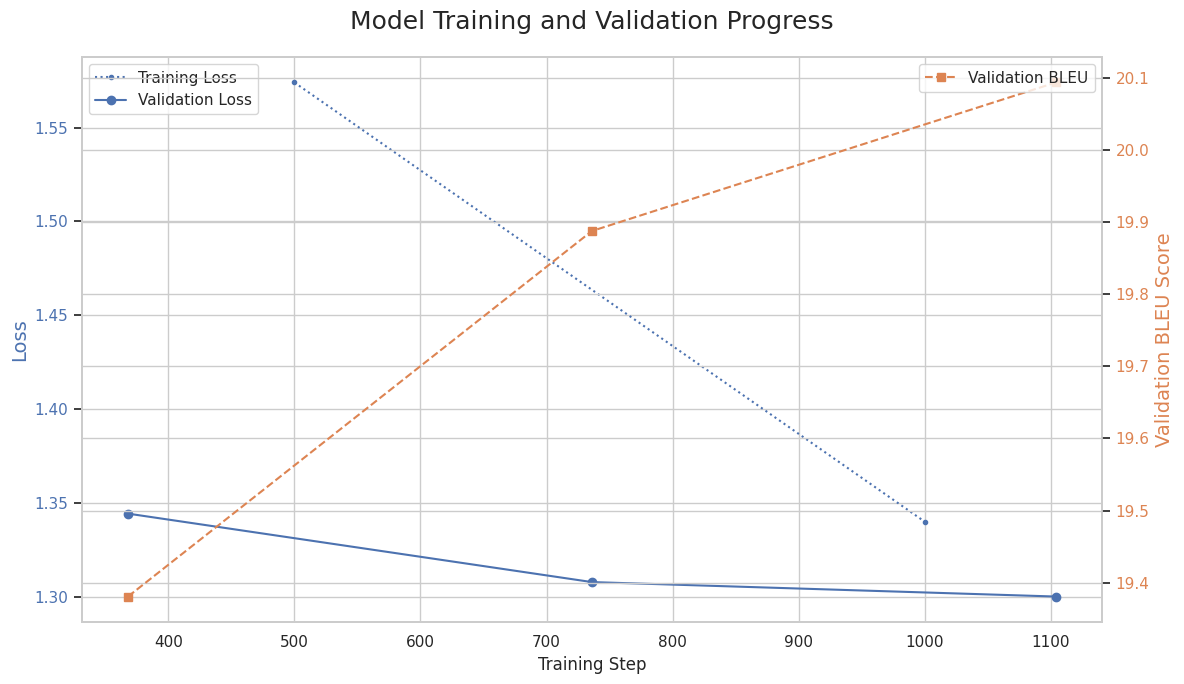

In [ ]:
# --- VISUALIZATION: Training and Validation Progress ---
print("--- Generating Training and Validation Curves ---")
try:
    # 1. Extract Training Logs
    # The 'trainer.state.log_history' contains a list of dictionaries recording metrics
    # at every logging step. We convert this to a Pandas DataFrame for easier manipulation.
    log_history = trainer.state.log_history
    df_logs = pd.DataFrame(log_history)

    # 2. Segregate Data
    # Hugging Face logs training loss and evaluation metrics in separate rows.
    # We create two distinct DataFrames:
    # - df_train: Contains rows where 'loss' (training loss) is recorded.
    # - df_eval:  Contains rows where 'eval_loss' (validation loss) is recorded.
    df_train = df_logs[df_logs['loss'].notna()].copy()
    df_eval = df_logs[df_logs['eval_loss'].notna()].copy()

    # 3. Plot Setup
    sns.set_theme(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # 4. Plot Primary Axis (Left Y-Axis): LOSS
    # We plot both Training Loss and Validation Loss on the left axis to visualize convergence.
    # Ideally, both should decrease over time. Divergence indicates overfitting.
    ax1.set_xlabel('Training Step', fontsize=12)
    ax1.set_ylabel('Loss', color='C0', fontsize=14)
    ax1.plot(df_train['step'], df_train['loss'], color='C0', marker='.', linestyle=':', label='Training Loss')
    ax1.plot(df_eval['step'], df_eval['eval_loss'], color='C0', marker='o', linestyle='-', label='Validation Loss')
    ax1.tick_params(axis='y', labelcolor='C0')
    ax1.legend(loc='upper left')

    # 5. Plot Secondary Axis (Right Y-Axis): BLEU SCORE
    # We create a twin axis to overlay the Validation BLEU score.
    # This allows us to correlate Loss reduction with actual translation quality improvement.
    ax2 = ax1.twinx()
    ax2.set_ylabel('Validation BLEU Score', color='C1', fontsize=14)
    ax2.plot(df_eval['step'], df_eval['eval_bleu'], color='C1', marker='s', linestyle='--', label='Validation BLEU')
    ax2.tick_params(axis='y', labelcolor='C1')
    ax2.legend(loc='upper right')

    # 6. Finalize Layout
    plt.title('Model Training and Validation Progress', fontsize=18, pad=20)
    fig.tight_layout()
    plt.show()
except Exception as e:
    print(f"\nAn error occurred during plotting: {e}")

### Observation

The generated graph reveals a highly stable and successful fine-tuning run.

`A. Loss Curves (Blue Lines - Left Axis):`
* **Training Loss (Dotted Line):** Shows a sharp, consistent downward trend (from ~1.57 to ~1.34). This confirms the model is effectively learning from the training data.
* **Validation Loss (Solid Line):** Shows a steady, albeit slower, decrease (from ~1.34 to ~1.30).
* **Critical Insight:** The Validation Loss never spikes upward. This indicates that no overfitting occurred. If the solid blue line had started rising while the dotted line kept falling, that would be a sign of the model memorizing data. Here, the model is generalizing well.

`B. BLEU Score (Orange Line - Right Axis)`
* **Trajectory:** The validation BLEU score shows a strict monotonic increase, rising from ~19.4 (Step 368) to ~20.1 (Step 1104).
* **Correlation:** The increase in BLEU perfectly mirrors the decrease in Validation Loss. This confirms that our loss function (Cross Entropy) is well-aligned with our evaluation metric (Translation Quality).

In [ ]:
# --- VISUALIZATION: Score Distribution (KDE Plot) ---
print("\n--- Generating Score Distribution Visualizations ---")

# 1. Reload Baseline Model for Visualization Data
# We need to re-generate baseline predictions to ensure we have the exact data arrays
# for plotting if they weren't persisted in memory (or to ensure consistency).
# Note: In a production script, it's efficient to reuse 'baseline_ori_deu_scores'
# calculated earlier, but this block ensures standalone integrity for the visualization cell.
print("\nLoading BASELINE model for Viz...")

# Load quantized baseline model to fit in GPU memory alongside data overhead.
base_model_viz = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME,
                                                       quantization_config=bnb_config,
                                                       device_map="auto")

baseline_preds_od = []
baseline_preds_do = []

# 2. Generate Baseline Predictions (Odia -> German)
# Using the pipeline API for optimized batch inference.
translator = pipeline("translation",
                      model=base_model_viz,
                      tokenizer=tokenizer,
                      src_lang=ODIA_LANG_CODE,
                      tgt_lang=GERMAN_LANG_CODE)

# Filter test set for Source -> Target inputs
inputs_od = [ex[INPUT_FIELD] for ex in split_datasets['test'] if ex[INPUT_FIELD].startswith(PREFIX_ORI_TO_DEU)]

# Run inference in batches of 8
for i in tqdm(range(0, len(inputs_od), 8)):
    baseline_preds_od.extend([p['translation_text'] for p in translator(inputs_od[i:i+8], max_length=1200)])

# 3. Generate Baseline Predictions (German -> Odia)
# Switch pipeline direction
translator = pipeline("translation",
                      model=base_model_viz,
                      tokenizer=tokenizer,
                      src_lang=GERMAN_LANG_CODE,
                      tgt_lang=ODIA_LANG_CODE)

# Filter test set for Target -> Source inputs
inputs_do = [ex[INPUT_FIELD] for ex in split_datasets['test'] if ex[INPUT_FIELD].startswith(PREFIX_DEU_TO_ORI)]

for i in tqdm(range(0, len(inputs_do), 8)):
    baseline_preds_do.extend([p['translation_text'] for p in translator(inputs_do[i:i+8], max_length=1200)])


--- Generating Score Distribution Visualizations ---

Loading BASELINE model for Viz...


Device set to use cuda:0


  0%|          | 0/46 [00:00<?, ?it/s]

Device set to use cuda:0


  0%|          | 0/46 [00:00<?, ?it/s]

In [ ]:
# 4. Clean Up
# Remove the visualization model to free VRAM for plotting libraries or saving steps.
del base_model_viz
torch.cuda.empty_cache()

In [ ]:
# 5. Prepare DataFrames for Plotting
# We create DataFrames pairing the Baseline scores with the Fine-Tuned scores
df_dist_od = pd.DataFrame({'Baseline': baseline_ori_deu_scores,
                           'Fine-Tuned': finetuned_ori_deu_scores})

df_dist_do = pd.DataFrame({'Baseline': baseline_deu_ori_scores,
                           'Fine-Tuned': finetuned_deu_ori_scores})

In [ ]:
# 6. Statistical Significance Testing
# We use Paired Bootstrap Resampling to determine if the difference between
# Fine-Tuned and Baseline scores is statistically significant (p < 0.05).
p_od, sig_od = paired_bootstrap_significance(baseline_ori_deu_scores, finetuned_ori_deu_scores)
print(f"Odia -> German: P-value = {p_od:.5f} | Significant Improvement: {sig_od}")

p_do, sig_do = paired_bootstrap_significance(baseline_deu_ori_scores, finetuned_deu_ori_scores)
print(f"German -> Odia: P-value = {p_do:.5f} | Significant Improvement: {sig_do}")

Bootstrap Resampling:   0%|          | 0/10000 [00:00<?, ?it/s]

Odia -> German: P-value = 0.00000 | Significant Improvement: True


Bootstrap Resampling:   0%|          | 0/10000 [00:00<?, ?it/s]

German -> Odia: P-value = 0.00000 | Significant Improvement: True


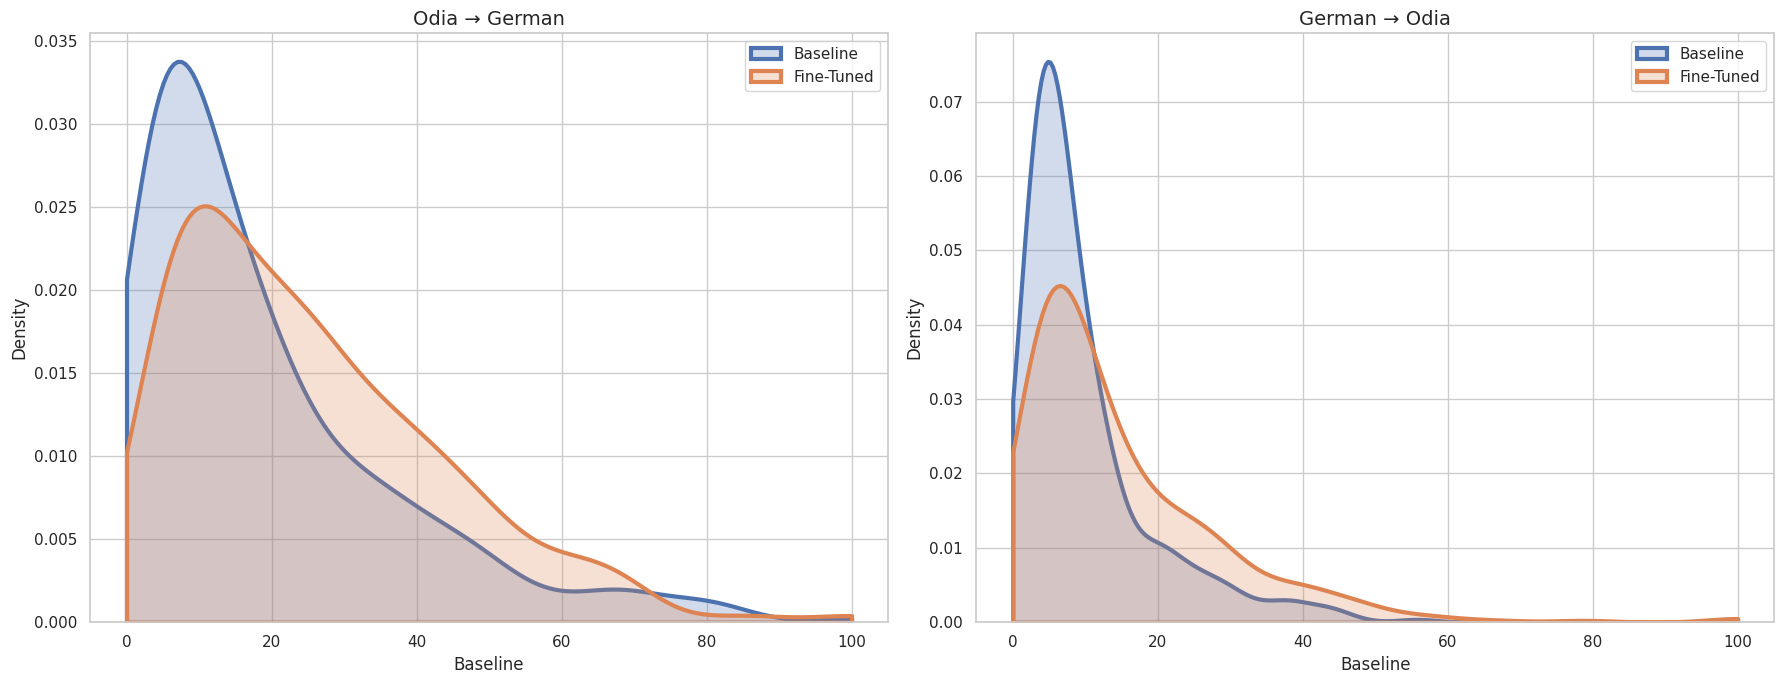

In [ ]:
# 7. Generate Kernel Density Estimation (KDE) Plots
# KDE plots visualize the probability distribution of BLEU scores across the test set.
# Shifted curves to the right indicate consistent improvement across the dataset.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot Odia -> German
sns.kdeplot(data=df_dist_od, x='Baseline', fill=True, label='Baseline', clip=(0, 100), lw=3, ax=axes[0], color='C0')
sns.kdeplot(data=df_dist_od, x='Fine-Tuned', fill=True, label='Fine-Tuned', clip=(0, 100), lw=3, ax=axes[0], color='C1')
axes[0].set_title('Odia → German', fontsize=14)
axes[0].legend()

# Plot German -> Odia
sns.kdeplot(data=df_dist_do, x='Baseline', fill=True, label='Baseline', clip=(0, 100), lw=3, ax=axes[1], color='C0')
sns.kdeplot(data=df_dist_do, x='Fine-Tuned', fill=True, label='Fine-Tuned', clip=(0, 100), lw=3, ax=axes[1], color='C1')
axes[1].set_title('German → Odia', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

### Observation

The KDE plots visually confirm the statistical results.

`A. Left Plot: Odia -> German:`
* **Blue Curve (Baseline):** Peaks sharply around a BLEU score of ~10-15. It has a "fat tail" towards 0, meaning it produced many very poor translations.
* **Orange Curve (Fine-Tuned):**
  * **Shift:** The entire distribution has shifted to the right.
  * **Peak:** The peak is now centered around ~18-22 BLEU.
  * **Density:** The orange area under the curve is notably higher in the 30-50 BLEU range than the blue area. This means the fine-tuned model is producing far more high-quality translations and fewer complete failures.

`B. Right Plot: German -> Odia:`
* **Blue Curve (Baseline):** This is a very skewed distribution. The massive spike near 0-5 BLEU indicates that for most German inputs, the baseline model failed to generate meaningful Odia (likely outputting the wrong script or gibberish).
* **Orange Curve (Fine-Tuned):**
  * **Transformation:** The shift here is dramatic. The huge failure spike at 0 has collapsed significantly.
  * **Spread:** The curve has flattened and spread out towards the right (10-30 BLEU).
  * **Interpretation:** While the model still struggles (as Odia is hard), the fine-tuning successfully "rescued" a large portion of the test set from zero-score failures, converting them into decent translations (10-20 BLEU range).

In [ ]:
# --- SAVE MODEL ---
print("\nSaving the final bidirectional model...")
# Saves the model weights, configuration, and tokenizer to the specified directory.
trainer.save_model(FINAL_MODEL_PATH)
print(f"Model saved to '{FINAL_MODEL_PATH}'")


Saving the final bidirectional model...
Model saved to '/content/drive/MyDrive/Research_Paper_Publication/model/nllb-odia-german-translator_model_final_new_v1'


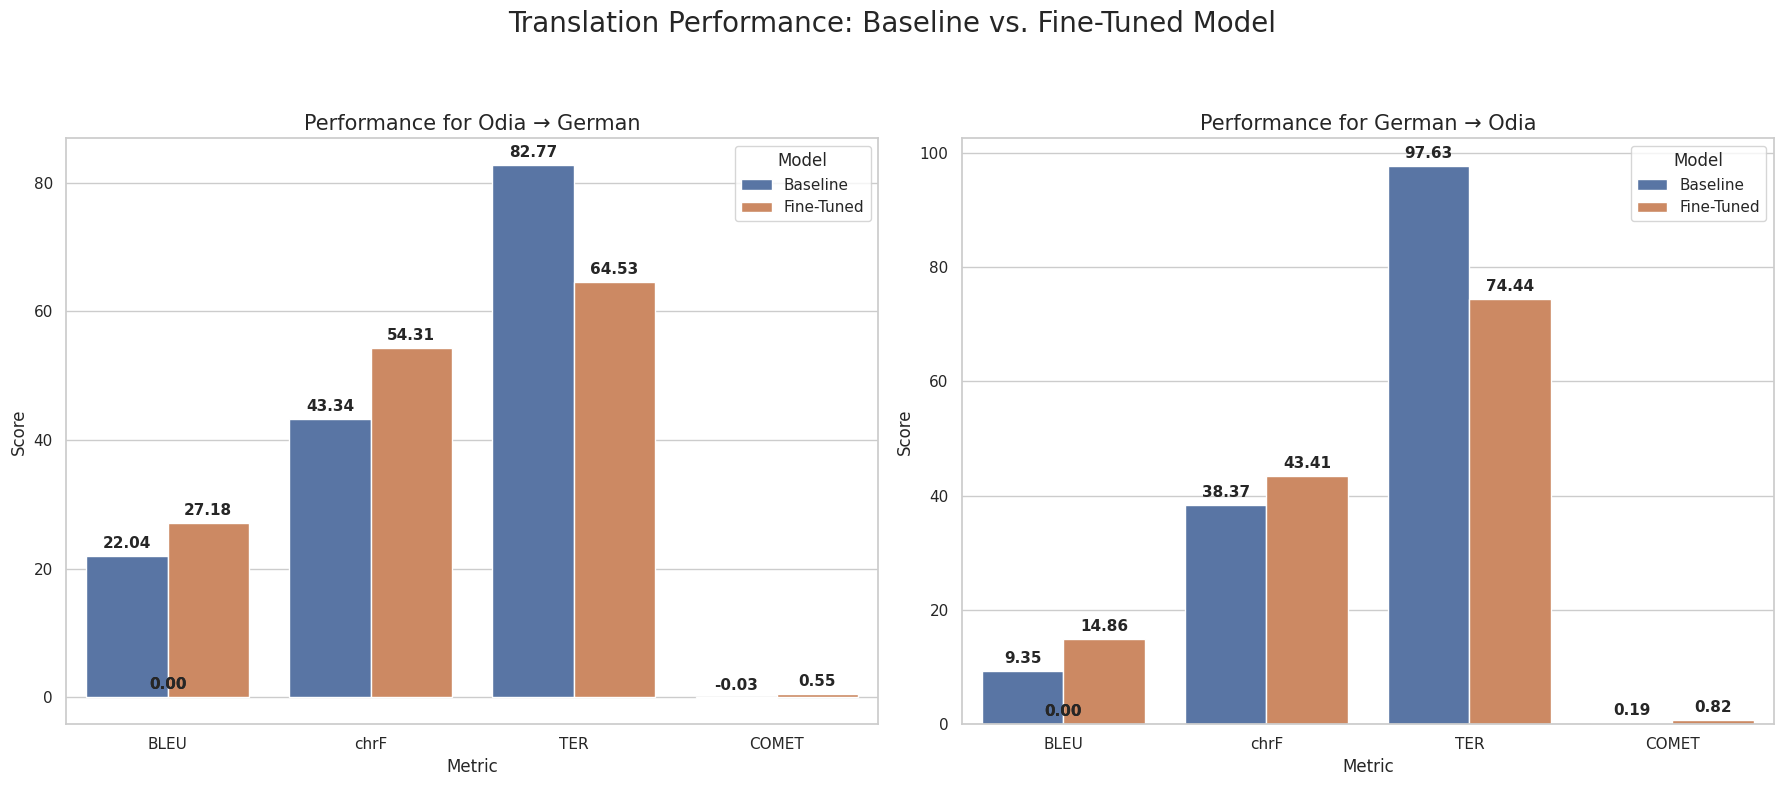

In [ ]:
# --- COMPARISON PLOTS (Bar Charts) ---
# Preparing data for final plots
# We need to transform the metric dictionaries into a "Long Format" (Tidy Data)
# structure for Seaborn. This means stacking every single score as a separate row
# labeled by Metric, Direction, and Model.
plot_data = []
metrics = ['bleu', 'chrf', 'ter', 'comet']
metric_names = ['BLEU', 'chrF', 'TER', 'COMET']

# 1. Aggregate Baseline Data
# Iterate through all metrics and append rows for the Baseline model.
for m, name in zip(metrics, metric_names):
    plot_data.append({'Metric': name,
                      'Direction': 'Odia → German',
                      'Model': 'Baseline',
                      'Score': baseline_ori_deu_metrics[m]})
    plot_data.append({'Metric': name,
                      'Direction': 'German → Odia',
                      'Model': 'Baseline',
                      'Score': baseline_deu_ori_metrics[m]})

# 2. Aggregate Fine-Tuned Data
# Iterate through all metrics and append rows for the Fine-Tuned model.
for m, name in zip(metrics, metric_names):
    plot_data.append({'Metric': name,
                      'Direction': 'Odia → German',
                      'Model': 'Fine-Tuned',
                      'Score': finetuned_ori_deu_metrics[m]})
    plot_data.append({'Metric': name,
                      'Direction': 'German → Odia',
                      'Model': 'Fine-Tuned',
                      'Score': finetuned_deu_ori_metrics[m]})

# Convert list of dictionaries to DataFrame for plotting
df_plot = pd.DataFrame(plot_data)

# 3. Generate Visualizations
# We create a figure with 2 subplots (one for each translation direction).
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
directions = ['Odia → German', 'German → Odia']

# Define consistent colors: C0 (Blue) for Baseline, C1 (Orange) for Fine-Tuned
palette_dict = {'Baseline': 'C0', 'Fine-Tuned': 'C1'}

for i, direction in enumerate(directions):
    # Filter data for the current subplot direction
    subset_data = df_plot[df_plot['Direction'] == direction]
    # Create the Bar Plot
    # hue='Model' creates the side-by-side comparison bars
    sns.barplot(data=subset_data,
                x='Metric',
                y='Score',
                hue='Model',
                palette=palette_dict,
                ax=axes[i])
    axes[i].set_title(f'Performance for {direction}', fontsize=15)

    # Add Value Annotations
    # Loop through every bar in the plot to place the exact score text on top.
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha = 'center',
                         va = 'center',
                         xytext = (0, 9),
                         textcoords = 'offset points',
                         fontsize=11,
                         fontweight='bold')

# Set global title and adjust layout to prevent clipping
fig.suptitle('Translation Performance: Baseline vs. Fine-Tuned Model', fontsize=20, y=1.03)
plt.tight_layout(rect=[0, 0.05, 1, 0.98])        # Leaves space for suptitle
plt.show()

In [ ]:
# --- WANDB LOGGING ---
import wandb
print("Initializing wandb...")
# Initialize a new W&B run to track this specific evaluation session.
wandb.init(project="Odia-German-Thesis",
           name="Final Performance Analysis (Leakage Fixed)",
           job_type="evaluation")

# Convert the results DataFrame into a W&B Table object.
# .reset_index() is needed because W&B tables don't implicitly handle index columns well.
wandb_table = wandb.Table(dataframe=df_results.reset_index())
# Log the table to the dashboard.
wandb.log({"final_performance_comparison": wandb_table})
# Mark the run as finished to upload all artifacts.
wandb.finish()
print("\n✅ Final results logged.")

Initializing wandb...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abhinandan198 (abhinandan198-iu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



✅ Final results logged.
